In [158]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import re
from sklearn.linear_model import LinearRegression

In [164]:
ROOT = Path.cwd()
DATA_DIR = ROOT/ "datasets"
IPEDS_DIR = DATA_DIR / "ipeds"
PROCESSED_DIR = IPEDS_DIR / "processed"

FRED_PATH = DATA_DIR / "fred"

In [165]:
application_fee_data = pd.read_csv(PROCESSED_DIR / "merged_application_fees.csv")
extra = application_fee_data.T.reset_index()
extra

,index,0,1,2,3,4,5,6,7,8,...,22844,22845,22846,22847,22848,22849,22850,22851,22852,22853
0,UNITID,14,1025,1408,1593,1595,1627,1733,1755,1942,...,500388,500397,500403,500412,500421,500430,500449,500467,500537,500555
1,1986,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1987,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1988,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1989,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,1990,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,1991,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,1992,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,1993,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,1994,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [166]:
df = application_fee_data.T.reset_index()
df.columns = df.iloc[0]
df = df.rename(columns={"UNITID": "YEAR"})
df = df.drop(0)
# df = df.rename(columns={df.columns[0]: "YEAR"})
# df = df.set_index(df.iloc[:, 0])
# df = df.drop(df.columns[0], axis=1)
df = df.replace(".", 0)
df = df.astype(float)
df.columns = df.columns.astype(str)
df

,YEAR,14,1025,1408,1593,1595,1627,1733,1755,1942,...,500388,500397,500403,500412,500421,500430,500449,500467,500537,500555
1,1986.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1987.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1988.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1989.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,1990.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,1991.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,1992.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,1993.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,1994.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10,1995.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


<Axes: xlabel='YEAR'>

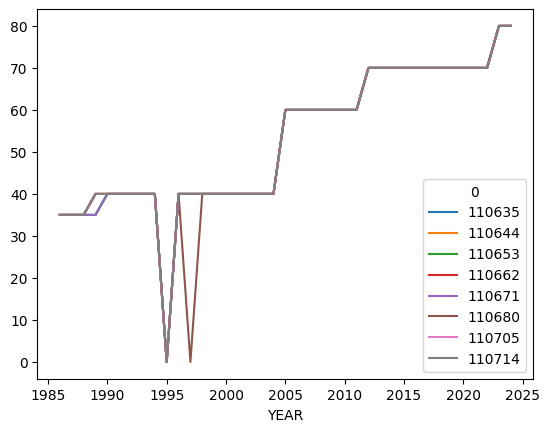

In [167]:
# school_to_unitid = {
#     "University of California-Berkeley": 110635,
#     "University of California-Davis": 110644,
#     "University of California-Irvine": 110653,
#     "University of California-Los Angeles": 110662,
#     "University of California-Riverside": 110671,
#     "University of California-San Diego": 110680,
#     "University of California-Santa Barbara": 110705,
#     "University of California-Santa Cruz": 110714,
# }
unitids = [
    "110635",
    "110644",
    "110653",
    "110662",
    "110671",
    "110680",
    "110705",
    "110714",
]

# all graphs are the exact same
df.plot(x="YEAR", y=unitids)

In [168]:
inflation = pd.read_csv(FRED_PATH / "CPALTT01USA661S.csv")

# getting most recent year of application fee data; inflation data should never bottleneck
inflation.iloc[:, 0] = inflation.iloc[:,0].map(lambda date : re.search(r"\d{4}", date).group())
inflation = inflation.astype(float)
inflation = inflation.rename(columns={"observation_date" : "YEAR"})

In [169]:
inflation_adjusted = pd.merge(df, inflation, on="YEAR", how="inner")
inflation_adjusted

,YEAR,14,1025,1408,1593,1595,1627,1733,1755,1942,...,500397,500403,500412,500421,500430,500449,500467,500537,500555,CPALTT01USA661S
0,1986.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,46.24493
1,1987.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,47.93960
2,1988.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,49.89445
3,1989.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,52.30286
4,1990.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,55.12614
5,1991.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,57.46072
6,1992.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,59.20110
7,1993.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,60.94851
8,1994.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,62.53771
9,1995.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,64.29215


In [170]:
inflation_adjusted.iloc[:, 1:-1] = inflation_adjusted.iloc[:, 1:-1].mul(100 / inflation_adjusted.iloc[:, -1], axis = 0)
inflation_adjusted

,YEAR,14,1025,1408,1593,1595,1627,1733,1755,1942,...,500397,500403,500412,500421,500430,500449,500467,500537,500555,CPALTT01USA661S
0,1986.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,46.24493
1,1987.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,47.93960
2,1988.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,49.89445
3,1989.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,52.30286
4,1990.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,55.12614
5,1991.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,57.46072
6,1992.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,59.20110
7,1993.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,60.94851
8,1994.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,62.53771
9,1995.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,64.29215


<Axes: xlabel='YEAR'>

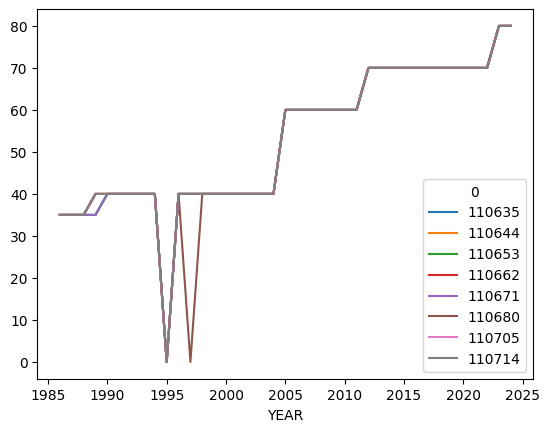

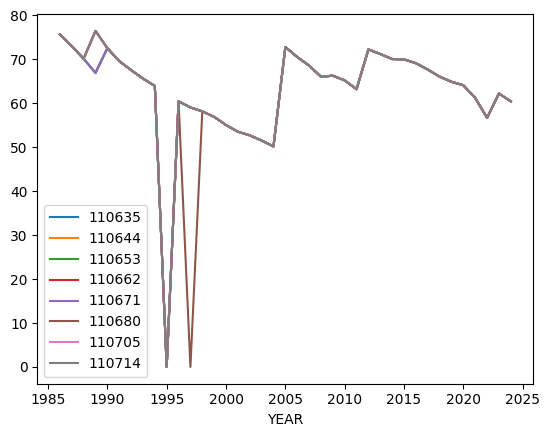

In [171]:
df.plot(x="YEAR", y=unitids)
inflation_adjusted.plot(x="YEAR", y=unitids)

Coefficients: [1.33805668]
Intercept: -2630.2395411605953


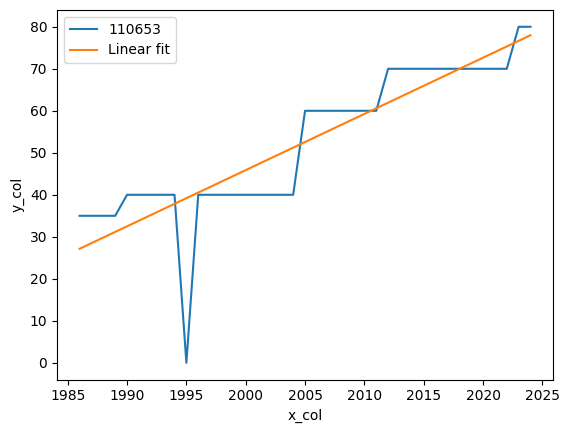

Coefficients: [0.05723269]
Intercept: -51.89287302174514


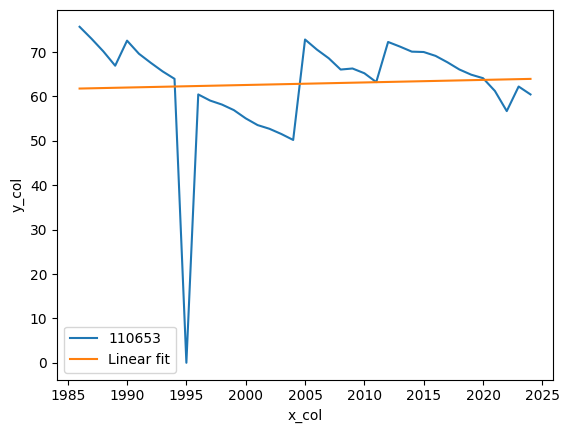

In [172]:
unitids = ["110653"]
for schoolid in unitids:
    model = LinearRegression(fit_intercept=True)

    # x
    years = pd.DataFrame(df["YEAR"])

    #y
    app_cost = df[schoolid]
    inflat_app_cost = inflation_adjusted[schoolid]

    # model and plot for non inflation-adjusted data
    model.fit(years, app_cost)
    print("Coefficients:", model.coef_)
    print("Intercept:", model.intercept_)
    y_pred = model.predict(years)
    
    df.plot(x="YEAR", y=unitids)
    plt.plot(years, y_pred, label="Linear fit")
    plt.xlabel("x_col")
    plt.ylabel("y_col")
    plt.legend()
    plt.show()

    # inflation-adjusted
    model.fit(years, inflat_app_cost)
    print("Coefficients:", model.coef_)
    print("Intercept:", model.intercept_)
    y_pred = model.predict(years)
    
    inflation_adjusted.plot(x="YEAR", y=unitids)
    plt.plot(years, y_pred, label="Linear fit")
    plt.xlabel("x_col")
    plt.ylabel("y_col")
    plt.legend()
    plt.show()